|<img style="float:left;" src="http://pierreproulx.espaceweb.usherbrooke.ca/usherb_transp.gif" width=50% height=50%> | ** Examen intra **|
|:---|:---|
|** Faculté de génie ** |    Pierre Proulx |
|Département de génie chimique et de génie biotechnologique |GCH200-Phénomènes d'échanges I |
| 11 octobre 2018 | 14:30 - 15:20 |
| locaux | C1-5026, C1-5028, C1-5020 |

### Examen intra corrigé, GCH200 Phénomènes d'échanges

### Deux fluides immiscibles s'écoulent par gravité sur un plan incliné

<img src="http://pierreproulx.espaceweb.usherbrooke.ca/images/intra1.png" align = "left" height="300"  width="300">

### Première partie du bilan et de la solution: "à la main"
### Partie A)
<img src='http://pierreproulx.espaceweb.usherbrooke.ca/images/Bilan_1.png'>


### **Partie B)**
<img src='http://pierreproulx.espaceweb.usherbrooke.ca/images/Bilan_2.png'>

### Partie D) On pose les 4 conditions ci-haut et on solutionne pour trouver les 4 constantes inconnues. On pose les 4 équations de conditions aux limites et on utilise solve de sympy.

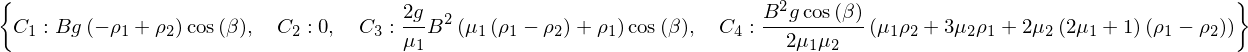

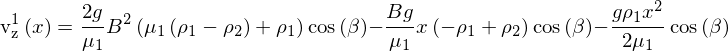

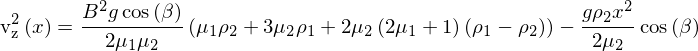

In [11]:
import sympy as sp
from IPython.display import *
sp.init_printing(use_latex=True)
import matplotlib.pyplot as plt
%matplotlib inline
x,C1,C2,C3,C4=sp.symbols('x,C1,C2,C3,C4')
rho_1,rho_2,B,g,beta,mu_1,mu_2=sp.symbols('rho_1,rho_2,B,g,beta,mu_1,mu_2')
#
# On recopie les 4 équations obtenues à la main en A et B)
#
tauxz1=rho_1*g*sp.cos(beta)*x+C1
tauxz2=rho_2*g*sp.cos(beta)*x+C2
vz1=-rho_1*g*sp.cos(beta)/2/mu_1*x**2-C1*x/mu_1+C3
vz2=-rho_2*g*sp.cos(beta)/2/mu_2*x**2-C2*x/mu_2+C4
#
# 4 conditions aux limites posées en C)
#
condition1=sp.Eq(C2,0) # taux de cisaillement nul en x=0, pour le fluide 2
condition2=sp.Eq(rho_2*g*sp.cos(beta)*B+C2,rho_1*g*sp.cos(beta)*B+C1) # taux de cisaillement égaux en x=B
condition3=sp.Eq(-rho_1*g*sp.cos(beta)/2/mu_1*B**2-C1*B/mu_1+C3,-rho_2*g*sp.cos(beta)/2/mu_2*B**2-C2*B/mu_2+C4) # vitesses égales en x=B
condition4=sp.Eq(-2*rho_1*g*sp.cos(beta)/mu_1*B**2+2*C1*B+C3,0) # vitesse = 0 en x= 2B  pour le fluide 1
conditions=(condition1,condition2,condition3,condition4)
constantes=(C1,C2,C3,C4)
#
# solution et substitution pour avoir les formes finales
#
Const=sp.solve(conditions,constantes)
display(Const)
vz1=vz1.subs(Const)
vz2=vz2.subs(Const)
tauxz1=tauxz1.subs(Const)
tauxz2=tauxz2.subs(Const)
fv1=sp.Function('v_z^1')(x)  # ces lignes seulement pour afficher les équations
fv2=sp.Function('v_z^2')(x)    # sous forme v1(x)=, etc...
ft1=sp.Function('tau_xz^1')(x)    # elles n'ont aucune utilité autre que cela.
ft2=sp.Function('tau_xz^2')(x)    # elles ne sont évidemment pas nécessaires.
display(sp.Eq(fv1,vz1),sp.Eq(fv2,vz2),sp.Eq(ft1,tauxz1),sp.Eq(ft2,tauxz2))
# la fonction sp.Eq(premier terme,deuxième terme)
# met en forme l'équation : premier terme= deuxième terme
### On peut tout aussi bien faire:
#display(vz1,vz2,tauxz1,tauxz2)

### Partie E) Traçage des résultats, ici le dictionnaire est pour deux fluides identiques, ce qui permet de vérifier que la solution donne bien ce qu'on attend d'elle. Jouez avec les densités et les viscosités pour voir l'effet sur les profils, c'est l'avantage d'avoir fait le travail avec sympy. Dans l'examen les deux densités étaient du simple au double, et aussi pour les viscosités.

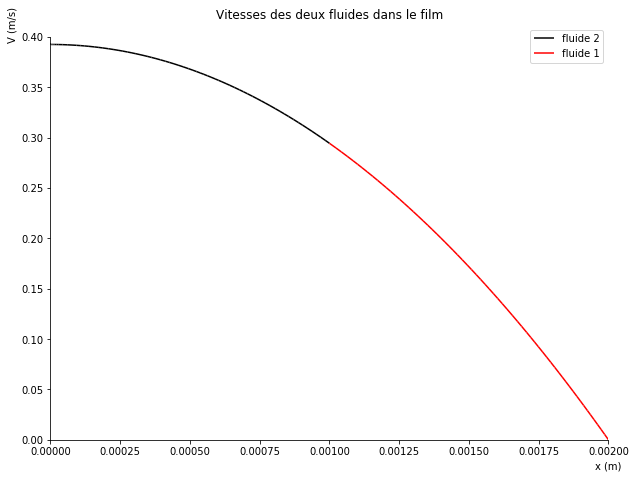

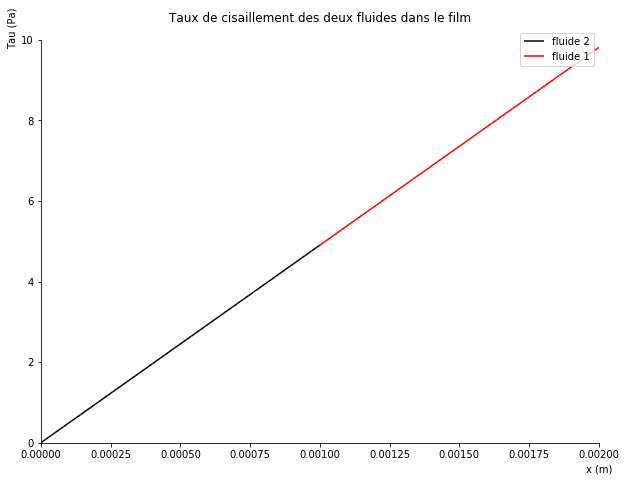

In [12]:
dico={
    'rho_1':1000,
    'rho_2':1000,
    'mu_1':0.025,
    'mu_2':0.025,
    'g':9.81,
    'beta':sp.pi/3,
    'B':0.001
    }
plt.rcParams['figure.figsize']=10,8
b=B.subs(dico)
b2=2*B.subs(dico)
V1=vz1.subs(dico)
V2=vz2.subs(dico)
p=sp.plot((V2,(x,0,b)),(V1,(x,b,b2)),ylabel='V (m/s)',xlabel='x (m)',legend=True,show=False)
p.title='Vitesses des deux fluides dans le film'
p[0].label='fluide 2'   # je sais, dans l'examen les deux indices étaient inversés dans le graphe
p[0].line_color='black' # ici ils sont ok. 
p[1].label='fluide 1'
p[1].line_color='red'
p.show();
#
Tau1=tauxz1.subs(dico)
Tau2=tauxz2.subs(dico)
p=sp.plot((Tau2,(x,0,b)),(Tau1,(x,b,b2)),ylabel='Tau (Pa)',xlabel='x (m)',legend=True,show=False)
p.title='Taux de cisaillement des deux fluides dans le film'
p[0].label='fluide 2'
p[0].line_color='black'
p[1].label='fluide 1'
p[1].line_color='red'
p.show();

### Partie F) points bonis. Ici j'en fais plus que demandé, les 4 premières lignes étaient suffisantes et un affichage 'fancy' n'était pas necessaire. La vitesse moyenne est égale au débit divisé par la section, La largeur de la plaque (W) n'apparaît pas dans la moyenne. Cette moyenne est donc calculée pour un film simple comme à la section 2.2: $$\frac{\int_0^W \int_0^B v(x) dxdy}{\int_0^W \int_0^B dxdy} $$ qui devient évidemment:$$\frac{W\int_0^B v(x) dx}{W\int_0^B dx} $$ c'est à dire: $$\frac{\int_0^B v(x) dx}{B} $$

### Pour les deux fluides on aura donc:$<v_2>=\frac{\int_0^B v_2(x)dx}{B} $ et $<v_1>=\frac{\int_B^{2B} v_1(x)dx}{B} $

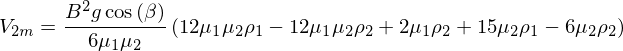

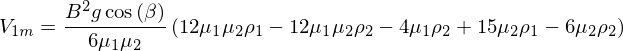

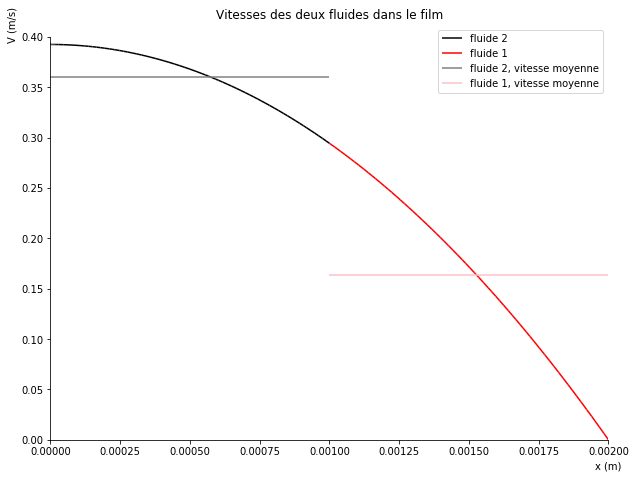

In [13]:
vmoyen2=sp.integrate(vz2,(x,0,B))/B
display(sp.Eq(sp.symbols('V_2m'),vmoyen2.simplify()),vmoyen2.subs(dico))
vmoyen1=sp.integrate(vz2,(x,B,2*B))/B
display(sp.Eq(sp.symbols('V_1m'),vmoyen1.simplify()),vmoyen1.subs(dico))
# Je recopie la section graphique pour la vitesse en ajoutant les deux vitesses moyennes
# sur le graphe
p=sp.plot((V2,(x,0,b)),(V1,(x,b,b2)),\
          (vmoyen2.subs(dico),(x,0,b)),(vmoyen1.subs(dico),(x,b,b2))\
          ,ylabel='V (m/s)',xlabel='x (m)',legend=True,show=False)
p.title='Vitesses des deux fluides dans le film'
p[0].label='fluide 2'
p[0].line_color='black'
p[1].label='fluide 1'
p[1].line_color='red'
p[2].label='fluide 2, vitesse moyenne'
p[2].line_color='grey'
p[3].label='fluide 1, vitesse moyenne'
p[3].line_color='pink'
p.show();